In [610]:
# import
import polars as pl
import pyarrow as pa
import statsmodels.api as sm
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as mtrans
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as mtick
from matplotlib import cm
from matplotlib.patches import Patch
# for using Times New Roman
import matplotlib.font_manager
import os as os
import subprocess
import sys as sys
import re
import threading
import logging
import time
import math
import warnings
warnings.filterwarnings('ignore')

In [611]:
# Using seaborn's style
plt.style.use(['ggplot', 'seaborn-v0_8-whitegrid'])

WIDTH = 345

def set_size(width, fraction=1):
    """ Set aesthetic figure dimensions to avoid scaling in latex.

    Parameters
    ----------
    width: float
            Width in pts
    fraction: float
            Fraction of the width which you wish the figure to occupy

    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio

    fig_dim = (fig_width_in, fig_height_in)

    return fig_dim

config = {
    "figure.figsize": set_size(WIDTH),
    "grid.linestyle": '--',
#     "hatch.color": '#eeeeee',
    "hatch.color": 'grey',
    "hatch.linewidth": 0.618,
    # Use LaTeX to write all text
    "text.usetex": False,
    "font.family": "Times New Roman",
    #"text.latex.unicode": True,
    "axes.unicode_minus": True,
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 22,
    "font.size": 22,
    "legend.fontsize": 22,
    # Make the label fonts a little smaller
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.handletextpad": 0.5,
    "legend.columnspacing": 0.9,
    "legend.numpoints": 3,
}

mpl.rcParams.update(config)

### comparison plot function

In [612]:
import os
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

save_pdf_path="."

def plot_prediction_error(
    p2p_df: pl.DataFrame,
    y_ticks=None,
    y_labels=None,
    figsize=(120, 24),
    pdf_filename=None,
    xlabel="Msg Size (B)",
    ylabel="Pred. Error",
    legend=True,
    legend_loc="upper center",
    legend_ncol=3,
    protocol=None
):
    # Compute prediction error
    p2p_df = p2p_df.with_columns(
        ((pl.col("latency_pre (us)") - pl.col("latency (us)")) / pl.col("latency (us)")).alias("prediction_error")
    )
    df_pd = p2p_df.to_pandas()

    plt.rcParams['axes.edgecolor'] = 'black'
    plt.figure(figsize=figsize)

    for nch in sorted(df_pd["nnodes"].unique()):
        df_sub = df_pd[(df_pd["nnodes"] == nch)]
        plt.semilogx(
            df_sub["msg"],  # B
            df_sub["prediction_error"],
            marker='o',
            linestyle='None',
            label=f'{nch} Nodes',
            markersize=3,
            base=2
        )

    # plt.xticks([0, 131072, 17179869184], labels=["0", "128 K", "16 G"])

    if protocol == "LL":
        x_ticks = [2**i for i in range(10, 40, 10)]  # Adjust range as needed
        x_labels = ["1 K", "1 M", "1 G"]  # Separate strings with commas
        plt.xticks(x_ticks, labels=x_labels, rotation=0)
    else:
        # Create log2-based ticks
        x_ticks = [2**i for i in range(10, 50, 10)]  # Adjust range as needed
        x_labels = ["1 K", "1 M", "1 G", "1 T"]  # Separate strings with commas
        plt.xticks(x_ticks, labels=x_labels, rotation=0)


    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.ylim(bottom=0)
    plt.gca().yaxis.set_label_coords(-0.2, 0.4)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    if y_ticks and y_labels:
        plt.yticks(y_ticks, labels=y_labels)

    if legend:
        plt.legend(ncol=legend_ncol, loc=legend_loc, bbox_to_anchor=(0.4, -0.5),
                   handlelength=1.2, handletextpad=0, columnspacing=0)

    plt.grid(True)
    plt.tight_layout()

    if pdf_filename:
        full_path = os.path.join(save_pdf_path, pdf_filename)
        plt.savefig(full_path, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {full_path}")

    plt.show()

In [613]:
import os
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def plot_prediction_error_nodes(
    p2p_df: pl.DataFrame,
    y_ticks=None,
    y_labels=None,
    figsize=(120, 24),
    pdf_filename=None,
    xlabel="# Nodes",
    ylabel="Perf. Diff.",
    legend=True,
    legend_loc="upper center",
    legend_ncol=3,
):
    # Compute prediction error
    p2p_df = p2p_df.with_columns(
        ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() / pl.col("latency (us)")).alias("prediction_error")
    )
    df_pd = p2p_df.to_pandas()

    plt.rcParams['axes.edgecolor'] = 'black'
    plt.figure(figsize=figsize)

    for nch in sorted(df_pd["nnodes"].unique()):
        df_sub = df_pd[(df_pd["nnodes"] == nch)]
        plt.semilogx(
            df_sub["nnodes"], 
            df_sub["prediction_error"],
            marker='o',
            linestyle='None',
            label='None',
            markersize=3,
            base=2
        )

    # Create log2-based ticks
    x_ticks = [2**i for i in range(2, 8, 1)]  # Adjust range as needed
    x_labels = ["4", "8", "16", "32", "64", "128"]  # Separate strings with commas
    plt.xticks(x_ticks, labels=x_labels, rotation=0)


    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.ylim(bottom=0)
    plt.gca().yaxis.set_label_coords(-0.2, 0.4)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    if y_ticks and y_labels:
        plt.yticks(y_ticks, labels=y_labels)

    if legend:
        plt.legend(ncol=legend_ncol, loc=legend_loc, bbox_to_anchor=(0.4, -0.5),
                   handlelength=1.2, handletextpad=0, columnspacing=0)

    plt.grid(True)
    plt.tight_layout()

    if pdf_filename:
        full_path = os.path.join(save_pdf_path, pdf_filename)
        plt.savefig(full_path, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {full_path}")

    plt.show()

In [614]:
def plot_latency_comparison(
    df,
    x_col='msg',
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured Latency', 'Predicted Latency'],
    markers=['o', '^'],
    colors=['#2980b9', '#e74c3c'],
    xlabel='Message Size (Bytes)',
    ylabel='Latency (ms)',
    pdf_filename='latency_comparison.pdf',
    legend_x=None,  # New parameter for x-location
    legend_y=None   # New parameter for y-location
):
    
    df = df.filter(pl.col("msg") < 18874368)

    # Convert to log scale for better visualization
    df_pandas = df.to_pandas().sort_values(by=x_col)
    
    # Convert microseconds to milliseconds
    df_pandas_ms = df_pandas.copy()
    for col in y_cols:
        df_pandas_ms[col] = df_pandas[col] / 1000.0  # Convert us to ms

    dim = set_size(WIDTH, fraction=1)
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Plot both lines (using millisecond values)
    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas_ms[x_col], df_pandas_ms[y], 
                label=label, marker=marker, markersize=4, 
                color=color, linewidth=1)

    # Set log scale for x-axis
    axe.set_xscale('log', base=2)
    
    # Set y-axis to start from 0
    axe.set_ylim(bottom=0)  # Add this line
    
    # Grid and axes settings
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Create log2-based ticks for x-axis
    x_ticks = [2**i for i in range(12, 25, 2)]
    x_labels = ["4K", "16K", "64K", "256K", "1M", "4M", "16M"]
    plt.xticks(x_ticks, labels=x_labels, rotation=15)

    # Create linear ticks for y-axis starting from 0
    y_max = df_pandas_ms[y_cols].max().max()
    y_ticks = np.linspace(0, y_max, 6)  # 6 ticks including 0
    plt.yticks(y_ticks)

    axe.set_xlabel(xlabel)
    axe.set_ylabel(ylabel)

    # Legend with custom location
    if legend_x is not None and legend_y is not None:
        # Use bbox_to_anchor for precise positioning
        axe.legend(
            bbox_to_anchor=(legend_x, legend_y),
            loc='center',  # This will be the anchor point
            frameon=False,
            handletextpad=0.5,
            columnspacing=1,
            handlelength=1.5
        )
    else:
        # Default legend positioning
        axe.legend(
            loc='lower right',
            frameon=False,
            handletextpad=0.5,
            columnspacing=1,
            handlelength=1.5
        )

    # Save to PDF if filename is provided
    if pdf_filename:
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {pdf_filename}")

    plt.show()

In [615]:
def plot_latency_comparison_nodes(
    df,
    x_col='nnodes',
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured Latency', 'Predicted Latency'],
    markers=['o', '^'],
    colors=['#2980b9', '#e74c3c'],
    xlabel='# Nodes',
    ylabel='Latency (ms)',  # Changed to ms
    pdf_filename='latency_comparison.pdf',
    protocol=None
):
    
    # Convert to log scale for better visualization
    df_pandas = df.to_pandas().sort_values(by=x_col)
    
    # Convert microseconds to milliseconds
    df_pandas_ms = df_pandas.copy()
    for col in y_cols:
        df_pandas_ms[col] = df_pandas[col] / 1000.0  # Convert us to ms

    dim = set_size(WIDTH, fraction=1)
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Plot both lines (using millisecond values)
    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas_ms[x_col], df_pandas_ms[y], 
                label=label, marker=marker, markersize=4, 
                color=color, linewidth=1)

    # Set log scale for x-axis
    axe.set_xscale('log', base=2)
    
    # Grid and axes settings
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Create log2-based ticks
    x_ticks = [2**i for i in range(2, 8, 1)]  # Adjust range as needed
    x_labels = ["4", "8", "16", "32", "64", "128"]  # Separate strings with commas
    plt.xticks(x_ticks, labels=x_labels, rotation=0)

    if protocol == "LL":
        y_ticks = [0, 20, 40]  # Adjust range as needed
        y_labels = ["0", "20", "40"]  # Separate strings with commas
    elif protocol == "LL128":
        y_ticks = [0, 150, 300]  # Adjust range as needed
        y_labels = ["0", "150", "300"]  # Separate strings with commas
    else:
        y_ticks = [0, 120, 240]  # Adjust range as needed
        y_labels = ["0", "120", "240"]  # Separate strings with commas
    plt.yticks(y_ticks, labels=y_labels, rotation=0)

    axe.set_xlabel(xlabel)
    axe.set_ylabel(ylabel)

    # Legend
    axe.legend(
        loc='upper left',
        frameon=False,
        handletextpad=0.5,
        columnspacing=1,
        handlelength=1.5
    )

    # Save to PDF if filename is provided
    if pdf_filename:
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {pdf_filename}")

    plt.show()

In [616]:
def plot_BW_comparison(
    df,
    x_col='msg',
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured BW', 'Predicted BW'],
    markers=['o', '^'],
    colors=['#2980b9', '#e74c3c'],
    xlabel='Message Size (Bytes)',
    ylabel='Latency (ms)',  # Changed to ms
    pdf_filename='latency_comparison.pdf',
    protocol=None,
    legend_x=None,  # New parameter for x-location
    legend_y=None   # New parameter for y-location    
):
    
    df = df.filter(pl.col("msg") > 16777216)

    # Convert to log scale for better visualization
    df_pandas = df.to_pandas().sort_values(by=x_col)
    
    # Convert microseconds to milliseconds
    df_pandas_ms = df_pandas.copy()
    for col in y_cols:
        df_pandas_ms[col] = df_pandas[col]

    dim = set_size(WIDTH, fraction=1)
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Plot both lines (using millisecond values)
    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas_ms[x_col], df_pandas_ms[y], 
                label=label, marker=marker, markersize=4, 
                color=color, linewidth=1)

    # Set log scale for x-axis
    axe.set_xscale('log', base=2)
    
    # Grid and axes settings
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    if protocol == "LL":
        x_ticks = [2**i for i in range(24, 29, 2)]  # Adjust range as needed
        x_labels = ["16M", "64M", "256M"]  # Separate strings with commas
        plt.xticks(x_ticks, labels=x_labels, rotation=0)
    else:
        # Create log2-based ticks
        x_ticks = [2**i for i in range(25, 34, 2)]  # Adjust range as needed
        x_labels = ["32M", "128M", "512M", "2G", "8G"]  # Separate strings with commas
        plt.xticks(x_ticks, labels=x_labels, rotation=15)
        axe.set_ylim(0, 400)  # Set y-axis limits from 0 to 400
        axe.set_yticks([100, 200, 300, 400])  # Set specific y-axis ticks

    axe.set_xlabel(xlabel)
    axe.set_ylabel(ylabel)

    # Legend with custom location
    if legend_x is not None and legend_y is not None:
        # Use bbox_to_anchor for precise positioning
        axe.legend(
            bbox_to_anchor=(legend_x, legend_y),
            loc='center',  # This will be the anchor point
            frameon=False,
            handletextpad=0.5,
            columnspacing=1,
            handlelength=1.5
        )
    else:
        # Default legend positioning
        axe.legend(
            loc='lower right',
            frameon=False,
            handletextpad=0.5,
            columnspacing=1,
            handlelength=1.5
        )

    # Save to PDF if filename is provided
    if pdf_filename:
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {pdf_filename}")

    plt.show()

### Read from Profiling

In [617]:
gpus_per_node = 8
FIFO_Depth = 4

In [618]:

import re
import polars as pl

def parse_send_timings(filename: str) -> pl.DataFrame:
    with open(filename, 'r') as f:
        text = f.read()

    # Modified regex to handle fractional message sizes
    info_re = re.compile(
        r"INFO: algo\((?P<algo>TREE|RING|NVLS_TREE|PAT)\)_protocol\((?P<protocol>Simple|LL|LL128)\)_mode\(reducescatter\)_message size\((?P<message_size>[\d/\.]+)\)"
        r"_nchannels\((?P<nchannels>\d+)\)"
        r"_nmessages\((?P<nmessages>\d+)\)"
        r"_iteration\((?P<iteration>\d+)\)"
    )

    info_matches = list(info_re.finditer(text))

    # Pattern for T0-T7 style chunks
    chunk_re = re.compile(
        r"-- \[T(?P<tag>[07])\] chunk (?P<chunk_id>\d+).*?"
        r"\(r(?P<source>\d+) to r(?P<dest>\d+)\) in channel (?P<channel>\d+): (?P<value>[\d.]+) ms"
    )

    # Additional pattern for T10 style chunks
    chunk_t10_re = re.compile(
        r"-- \[T(?P<tag>10)\] chunk 0 posted to chunk (?P<chunk_id>\d+) done time "
        r"\(r(?P<source>\d+) to r(?P<dest>\d+)\) in channel (?P<channel>\d+): (?P<value>[\d.]+) ms"
    )

    # Rest of the patterns remain the same
    t_tags_re = re.compile(
        r"-- \[T(?P<tag>[1289])\].*?time: (?P<value>[\d.]+) ms"
    )
    
    t_init_re = re.compile(
        r"-- \[T init\] nccl init time: (?P<value>[\d.]+) ms"
    )

    records = []
    for idx, m in enumerate(info_matches):
        meta = m.groupdict()  # Get all groups as strings first
        # Handle fractional message size
        if '/' in meta['message_size']:
            num, denom = map(float, meta['message_size'].split('/'))
            meta['message_size'] = num/denom
        else:
            meta['message_size'] = float(meta['message_size'])
            
        # Convert other numeric fields to int
        for k in ['nchannels', 'nmessages', 'iteration']:
            meta[k] = int(meta[k])
        start = m.end()
        end = info_matches[idx+1].start() if idx+1 < len(info_matches) else len(text)
        section = text[start:end]

        # Get T1, T2, T8, T9 timings
        t_timings = {
            f"T{e.group('tag')}": float(e.group('value'))
            for e in t_tags_re.finditer(section)
        }

        # Get init time
        ti = t_init_re.search(section)
        if ti:
            t_timings["T_init"] = float(ti.group("value"))

        # Process chunk data
        chunk_data = {}
        for c in chunk_re.finditer(section):
            cid = int(c.group("chunk_id"))
            ch = int(c.group("channel"))
            tag = f"T{c.group('tag')}"
            val = float(c.group('value'))
            source = int(c.group('source'))  # Extract source from regex
            dest = int(c.group('dest'))      # Extract dest from regex
            
            key = (cid, ch, meta["iteration"])
            if key not in chunk_data:
                chunk_data[key] = {
                    "chunk_id": cid,
                    "channel": ch,
                    "source": source,  # Use extracted values
                    "dest": dest,      # Use extracted values
                    **meta,
                    **t_timings
                }
            chunk_data[key][tag] = val

        # Process T10 chunks
        for c in chunk_t10_re.finditer(section):
            cid = int(c.group("chunk_id"))
            ch = int(c.group("channel"))
            tag = f"T{c.group('tag')}"
            val = float(c.group('value'))
            source = int(c.group('source'))
            dest = int(c.group('dest'))
            
            key = (cid, ch, meta["iteration"])
            if key not in chunk_data:
                chunk_data[key] = {
                    "chunk_id": cid,
                    "channel": ch,
                    "source": source,
                    "dest": dest,
                    **meta,
                    **t_timings
                }
            chunk_data[key][tag] = val

        records.extend(chunk_data.values())

    df = pl.DataFrame(records)
    print(f"Number of records: {len(records)}")  # Debug print
    return df

### Read from nccl-test data

In [619]:
def parse_nccl_output(file_path, gpus_per_node, msg_size_thresholds=None):
    """
    Parse NCCL test output file and create a DataFrame with performance data.
    
    Args:
        file_path (str): Path to the NCCL test output file
        gpus_per_node (int): Number of GPUs per node
        msg_size_thresholds (dict): Dictionary of message size thresholds and corresponding nchannels
                                  Default: {
                                      32*1024: 1,
                                      64*1024: 2,
                                      128*1024: 4,
                                      512*1024: 8,
                                      float('inf'): 16
                                  }
    
    Returns:
        pl.DataFrame: DataFrame containing the parsed data
    """
    # Set default thresholds if none provided
    if msg_size_thresholds is None:
        msg_size_thresholds = {
            32*1024: 16,
            64*1024: 16,
            128*1024: 16,
            512*1024: 16,
            float('inf'): 16
        }

    # Initialize lists to store the data
    sizes = []
    times = []
    busbws = []

    # Initialize configuration variables
    protocol = "unknown"
    algorithm = "unknown"
    max_rank = -1

    # Read and process file
    with open(file_path, 'r') as file:
        content = file.read()
        
        # Parse protocol
        if "NCCL_PROTO=" in content:
            protocol = content.split("NCCL_PROTO=")[1].split()[0].strip()
        
        # Parse algorithm
        if "NCCL_ALGO=" in content:
            algorithm = content.split("NCCL_ALGO=")[1].split()[0].strip()
        
        # Find max rank number
        for line in content.split('\n'):
            if line.startswith("#  Rank"):
                try:
                    rank_num = int(line.split()[2])
                    max_rank = max(max_rank, rank_num)
                except (ValueError, IndexError):
                    continue

        nnodes = (max_rank + 1)/gpus_per_node

        # Parse performance data
        for line in content.split('\n'):
            parts = line.strip().split()
            if len(parts) >= 8:
                try:
                    if (parts[0].replace(',', '').isdigit() and
                        parts[1].replace(',', '').isdigit() and
                        parts[2] == "float"):
                        
                        size = int(parts[0].replace(',', ''))
                        time = float(parts[5])
                        busbw = float(parts[7])
                        
                        sizes.append(size)
                        times.append(time)
                        busbws.append(busbw)
                except ValueError:
                    continue

    # Create DataFrame
    df = pl.DataFrame({
        "msg": sizes,
        "latency (us)": times,
        "BW (GB/s)": busbws
    })

    # Add configuration parameters
    df = df.with_columns([
        pl.lit(algorithm.upper()).alias("algorithm"),
        pl.lit(nnodes).alias("nnodes"),
        pl.lit(protocol).alias("protocol")
    ])

    # Add nchannels based on message size
    when_then_chain = pl.when(pl.col("msg") <= list(msg_size_thresholds.keys())[0])
    for i, (threshold, nchannels) in enumerate(msg_size_thresholds.items()):
        if i == 0:
            when_then_chain = when_then_chain.then(nchannels)
        elif i < len(msg_size_thresholds) - 1:
            when_then_chain = when_then_chain.when(pl.col("msg") <= threshold).then(nchannels)
        else:
            when_then_chain = when_then_chain.otherwise(nchannels)

    df_sweep_data_means = (df
        .sort("msg")
        .with_columns([when_then_chain.alias("nchannels")])
    )

    return df_sweep_data_means

# Example usage:
custom_thresholds = {
            1*1024: 1,
            2*1024: 2,
            4*1024: 4,
            8*1024: 8,
            float('inf'): 16
}

df_sweep_data_means = parse_nccl_output("./simple_profiling_results/nccl_test-reducescatter-ring.out", gpus_per_node=gpus_per_node, msg_size_thresholds=custom_thresholds)

# with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
#     print(df_sweep_data_means.to_pandas())

display(df_sweep_data_means)

msg,latency (us),BW (GB/s),algorithm,nnodes,protocol,nchannels
i64,f64,f64,str,f64,str,i32
8192,2226.8,0.0,"""RING""",16.0,"""Simple""",8
16384,2209.0,0.01,"""RING""",16.0,"""Simple""",16
32768,2170.2,0.01,"""RING""",16.0,"""Simple""",16
65536,2293.8,0.03,"""RING""",16.0,"""Simple""",16
131072,2356.1,0.06,"""RING""",16.0,"""Simple""",16
…,…,…,…,…,…,…
7516192768,20629.0,361.51,"""RING""",16.0,"""Simple""",16
8589934592,23344.0,365.1,"""RING""",16.0,"""Simple""",16
17179869184,46387.0,367.47,"""RING""",16.0,"""Simple""",16


### Read from profiling

In [620]:
# === File Paths ===
profiling_files = {
    "r1": "./simple_profiling_results/nccl_reducescatter_heo-inter_r-1.out"
}

# === Load Data ===
df_r1 = parse_send_timings(profiling_files["r1"])

# with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
#         print(df_r1.to_pandas())

display(df_r1)


Number of records: 1550


chunk_id,channel,source,dest,algo,protocol,message_size,nchannels,nmessages,iteration,T1,T2,T9,T8,T_init,T0,T7,T10
i64,i64,i64,i64,str,str,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
0,0,1,8,"""RING""","""Simple""",0.003906,1,10000,0,0.006005,0.016141,0.110288,0.004878,2122.985596,0.0,0.093416,0.104283
1,0,1,8,"""RING""","""Simple""",0.003906,1,10000,0,0.006005,0.016141,0.110288,0.004878,2122.985596,0.000074,0.092315,0.105022
2,0,1,8,"""RING""","""Simple""",0.003906,1,10000,0,0.006005,0.016141,0.110288,0.004878,2122.985596,0.000147,0.090002,0.106015
3,0,1,8,"""RING""","""Simple""",0.003906,1,10000,0,0.006005,0.016141,0.110288,0.004878,2122.985596,0.000219,0.088545,0.10646
4,0,1,8,"""RING""","""Simple""",0.003906,1,10000,0,0.006005,0.016141,0.110288,0.004878,2122.985596,0.104403,0.023844,0.134839
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
57,0,1,8,"""RING""","""Simple""",65536.0,16,10000,0,0.02691,0.073767,0.373239,0.078191,2355.945557,5.1434,0.292063,5.502998
58,0,1,8,"""RING""","""Simple""",65536.0,16,10000,0,0.02691,0.073767,0.373239,0.078191,2355.945557,5.234389,0.288386,5.589921
59,0,1,8,"""RING""","""Simple""",65536.0,16,10000,0,0.02691,0.073767,0.373239,0.078191,2355.945557,5.317344,0.280167,5.635845


### Parameter Analysis

### The message size in ReduceScatter is the size of the recvbuff (total communication size = nranks * recvbuff)

In [621]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def analyze_L_timing(df, nranks, slice_step, min_message_size, max_message_size, plot_figure):
    # (KB/ms = 0.001 GB/s)    
    
    df_filtered = df.filter(
     (pl.col("message_size") >= min_message_size) & 
     (pl.col("message_size") <= max_message_size)
    )

    # Get max chunk_id for each message_size
    max_chunk_id = 119
    min_chunk_id = 4

    df_filtered = (df_filtered
        .filter((pl.col("chunk_id") <= max_chunk_id) & (pl.col("chunk_id") >= min_chunk_id))
        .group_by(["message_size"])  # Include nchannels in group_by
        .agg([
            pl.col("T7").mean().alias("T7_mean"),
            pl.col("nchannels").first().alias("nchannels")  # Keep nchannels value
        ])
        .sort("message_size")
    )
    
    # Calculate X and y
    X = ((df_filtered['message_size']/(df_filtered['nchannels'] * nranks * slice_step)) * 0.001).to_numpy().reshape(-1, 1)
    y = (df_filtered['T7_mean']).to_numpy()
    
    # Perform linear regression
    reg = LinearRegression().fit(X, y)
    k = reg.coef_[0]   # slope
    s = reg.intercept_ # intercept
    r2 = reg.score(X, y)  # R-squared value
    
    if plot_figure == 1:
        # Create plot
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='blue', label='Actual data')
        plt.plot(X, reg.predict(X), color='red', label=f'Fitted line: y = {k:.6f}x + {s:.6f}')
        plt.xlabel('Message Size (MB)')
        plt.ylabel('Processing Time (ms)')
        plt.title(f't_i vs Message Size (R² = {r2:.4f})')
        plt.legend()
        plt.grid(True)
        plt.show()

    L = s * 1e3
    G_reverse = k # us/KB

    print(f"L (us) = {L:.3f}, R-squared value is {r2:.6f}")
    
    return L

def analyze_G_timing(df, nranks, slice_step, min_message_size, max_message_size, plot_figure):
    # (KB/ms = 0.001 GB/s)    
    
    df_filtered = df.filter(
     (pl.col("message_size") >= min_message_size) & 
     (pl.col("message_size") <= max_message_size)
    )

    # Get max chunk_id for each message_size
    max_chunks = (df_filtered
        .group_by("message_size")
        .agg(pl.col("chunk_id").max().alias("max_chunk_id"))
    )

    # Join back to get rows with max chunk_id for each message_size
    df_filtered = (df_filtered
        .join(max_chunks, on="message_size")
        .filter(pl.col("chunk_id") == pl.col("max_chunk_id"))
        .drop("max_chunk_id")
        .sort("message_size")
    )

    # with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    #     print(df_filtered.to_pandas())
    
    # Calculate X and y
    X = ((df_filtered['message_size']/(df_filtered['nchannels'] * nranks * slice_step)) * 0.001).to_numpy().reshape(-1, 1)
    y = (df_filtered['T9']-df_filtered['T2']).to_numpy()
    
    # Perform linear regression
    reg = LinearRegression().fit(X, y)
    k = reg.coef_[0]   # slope
    s = reg.intercept_ # intercept
    r2 = reg.score(X, y)  # R-squared value
    
    if plot_figure == 1:
        # Create plot
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='blue', label='Actual data')
        plt.plot(X, reg.predict(X), color='red', label=f'Fitted line: y = {k:.6f}x + {s:.6f}')
        plt.xlabel('Message Size (MB)')
        plt.ylabel('Processing Time (ms)')
        plt.title(f't_i vs Message Size (R² = {r2:.4f})')
        plt.legend()
        plt.grid(True)
        plt.show()

    L = s * 1e3
    G_reverse = k # us/KB

    print(f"G_reverse = {G_reverse:.3f} (us/KB), R-squared value is {r2:.6f}")
    
    return G_reverse


def analyze_G_v2_timing(df, slice_step, min_message_size, max_message_size, plot_figure):
    # (KB/ms = 0.001 GB/s)    
    
    df_filtered = df.filter(
     (pl.col("message_size") >= min_message_size) & 
     (pl.col("message_size") <= max_message_size)
    )

    # Get max chunk_id for each message_size
    max_chunk_id = (
        df_filtered
        .filter(pl.col("message_size") == pl.col("message_size").min())
        ["chunk_id"]
        .max() - FIFO_Depth
    )
    # min_chunk_id = FIFO_Depth

    min_chunk_id = 0

    df_filtered = (df_filtered
        .filter((pl.col("chunk_id") <= max_chunk_id) & (pl.col("chunk_id") >= min_chunk_id))
        .filter((pl.col("chunk_id").mod(FIFO_Depth) == FIFO_Depth-1))  # chunk_id = 4n-1
        .sort(["message_size", "chunk_id"])  # Important to sort before calculating diff
        .group_by("message_size")
        .agg([
            (pl.col("T10").diff().mean()).alias("T_G_mean"),  # Calculate diff and mean
            pl.col("nchannels").first().alias("nchannels")
        ])
        .sort("message_size")
    )

        
    # Calculate X and y
    X = ((df_filtered['message_size']/(df_filtered['nchannels'] * slice_step)) * 0.001).to_numpy().reshape(-1, 1)

    y = df_filtered["T_G_mean"].to_numpy()
    
    # Perform linear regression
    reg = LinearRegression().fit(X, y)
    k = reg.coef_[0]   # slope
    s = reg.intercept_ # intercept
    r2 = reg.score(X, y)  # R-squared value
    
    if plot_figure == 1:
        # Create plot
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='blue', label='Actual data')
        plt.plot(X, reg.predict(X), color='red', label=f'Fitted line: y = {k:.6f}x + {s:.6f}')
        plt.xlabel('Message Size (MB)')
        plt.ylabel('Processing Time (ms)')
        plt.title(f't_i vs Message Size (R² = {r2:.4f})')
        plt.legend()
        plt.grid(True)
        plt.show()

    L_G = s * 1e3
    G_reverse = k # us/KB

    print(f"G_reverse = {G_reverse:.3f} (us/KB), L_G = {L_G:.3f} (us), R-squared value is {r2:.6f}")

    # L_G, G_reverse are about the time of each 4n-1 chunk
    
    return G_reverse, L_G


def analyze_L_ss_timing(df, nranks, slice_step, G, min_message_size, max_message_size, plot_figure):
    # (KB/ms = 0.001 GB/s)  
    # 
    
    df_filtered = df.filter(
     (pl.col("message_size") >= min_message_size) & 
     (pl.col("message_size") <= max_message_size)
    )

    # with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    #     print(df_filtered.to_pandas())

    # Get max chunk_id for each message_size
    max_chunk_id = (
        df_filtered
        .filter(pl.col("message_size") == pl.col("message_size").min())
        ["chunk_id"]
        .max() - FIFO_Depth
    )
    min_chunk_id = FIFO_Depth+1

    df_filtered = (df_filtered
        .filter((pl.col("chunk_id") <= max_chunk_id) & (pl.col("chunk_id") >= min_chunk_id))
        .sort(["message_size", "chunk_id"])  # Important to sort before calculating diff
        .group_by("message_size")
        .agg([
            ((pl.col("T10")-pl.col("T0") - G * 1e-3 * pl.col("message_size") / (pl.col("nchannels") * nranks * slice_step * FIFO_Depth)).mean()).alias("T_G_mean"),
            pl.col("nchannels").first().alias("nchannels")
        ])
        .sort("message_size")
    )

    if plot_figure == 1:
        # Create plot
        plt.figure(figsize=(8, 5))
        
        # Get unique nchannels values
        unique_nchannels = sorted(df_filtered["nchannels"].unique())
        
        # Plot each nchannels group with different color
        for nchannel in unique_nchannels:
            subset = df_filtered.filter(df_filtered["nchannels"] == nchannel)
            plt.scatter(subset["message_size"]/(subset["nchannels"]*nranks * slice_step), 
                    subset["T_G_mean"], 
                    label=f'# channels = {nchannel}',
                    alpha=0.7)
        
        plt.xlabel('Chunk Size (KB)')
        plt.ylabel('L\' (ms)')
        plt.legend()
        plt.grid(True)
        plt.show()

    df_min_channels = df_filtered.filter(pl.col("message_size") < max_message_size)

    L = df_min_channels["T_G_mean"].mean() * 1e3

    print(f"L_G = {L:.3f} (us)")

    # L_G is about the time of each 4n-1 chunk
    
    return L

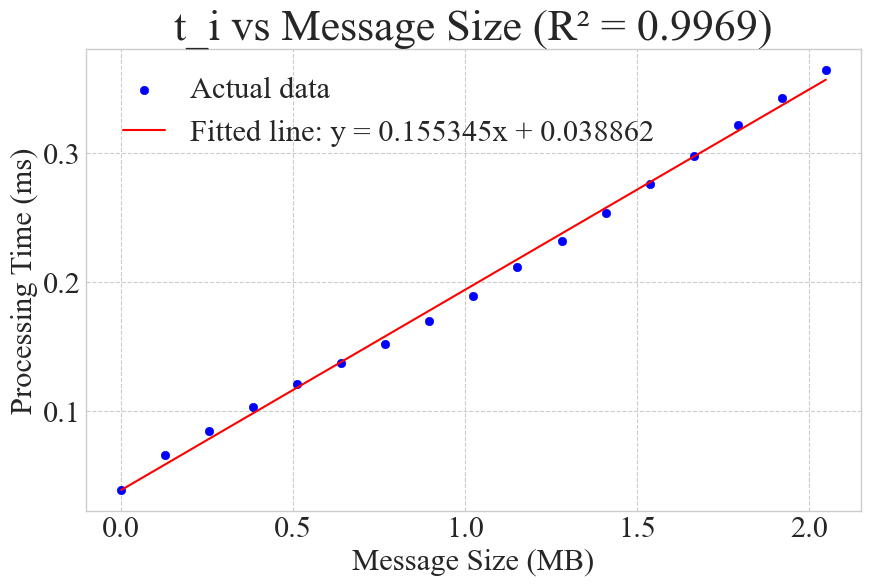

G_reverse = 0.155 (us/KB), L_G = 38.862 (us), R-squared value is 0.996854


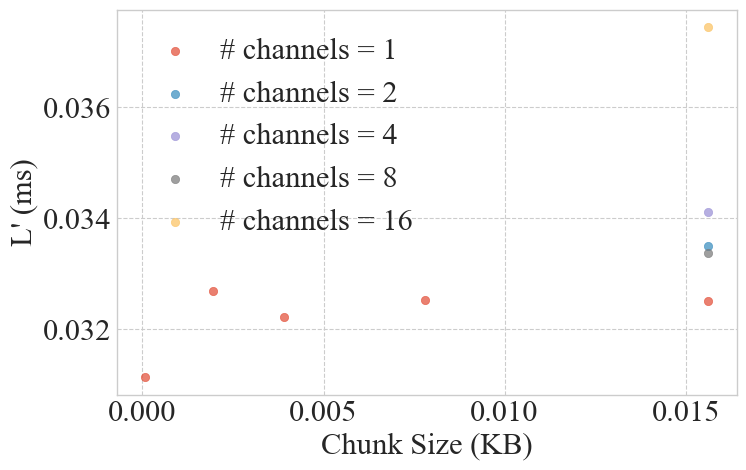

L_G = 32.761 (us)


In [622]:
# Usage:

# 16 KB is the thread size for each isend, 
# if the isend size <= 16 KB: proxy will send one chunk with data, then another chunk without data
# if the isend size is > 16 KB, each isend has data.
# the chunk size in GPU prims is 2 MB, in proxy is 1 MB, becasue the slicestep = 2.

nranks = 32
nchannels = 16
isend_chunk_size = 2048 # KB
ring_chunk_size_simple = isend_chunk_size
max_single_isend_of_two_steps_chunk_size = 1/2 # KB
slice_step = 2

# inflection_point1: the two chunks are both 16 KB and then increase with msg size increase.
inflection_point1 = nchannels * max_single_isend_of_two_steps_chunk_size * slice_step

# inflection_point2: now the chunk size is max, after this point, chunk size will not increase, chunk number increase.
inflection_point2 = isend_chunk_size * slice_step * nchannels

small_msg_start = 1/2

max_nchannels_start = 16

# L = analyze_L_timing(df_r1, nranks, 1, small_msg_start, max_nchannels_start/2, 0)

# L_G, G_reverse are about the time of each 4n-1 chunk
G_reverse, L_G = analyze_G_v2_timing(df_r1, slice_step, inflection_point1, inflection_point2, 1)
# G_reverse_small, L_G_small = analyze_G_v2_timing(df_r1, slice_step, max_nchannels_start, inflection_point1, 0)
L_G_ss = analyze_L_ss_timing(df_r1, nranks, slice_step, G_reverse, 0, max_nchannels_start, 1)

### Model Varification V2

### the msg in nccl-test is the total message size, for eanch rank, the send size = msg

msg,latency (us),BW (GB/s),algorithm,nnodes,protocol,nchannels,latency_pre (us),BW_pre (GB/s),prediction_error (%)
i64,f64,f64,str,f64,str,i32,f64,f64,f64
16384,2209.0,0.01,"""RING""",16.0,"""Simple""",16,2080.309885,0.007814,5.825718
32768,2170.2,0.01,"""RING""",16.0,"""Simple""",16,2080.309885,0.015628,4.14202
65536,2293.8,0.03,"""RING""",16.0,"""Simple""",16,2080.309885,0.031257,9.307268
131072,2356.1,0.06,"""RING""",16.0,"""Simple""",16,2080.309885,0.062514,11.705365
262144,2389.2,0.11,"""RING""",16.0,"""Simple""",16,2080.309885,0.125028,12.9286
…,…,…,…,…,…,…,…,…,…
7516192768,20629.0,361.51,"""RING""",16.0,"""Simple""",16,20144.670116,370.195812,2.347811
8589934592,23344.0,365.1,"""RING""",16.0,"""Simple""",16,22669.950712,375.952548,2.887463
17179869184,46387.0,367.47,"""RING""",16.0,"""Simple""",16,45339.901425,375.952548,2.25731


📄 Plot saved to: ./reducescatter_ring_simple_pre_error.pdf


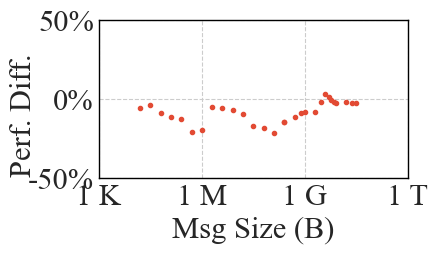

In [623]:
# use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.
number_channels = 16

df_sweep_data_means = df_sweep_data_means.filter(
        pl.col("msg") > 8192
)

max_nchannels_start_simple = max_nchannels_start

df_sweep_data_simple_ring_v1 = (df_sweep_data_means
    .with_columns([
        pl
        .when(
            (pl.col("msg")/1024) < max_nchannels_start * pl.col("nnodes")*gpus_per_node # when channels is not max
        )
        .then(
            L_G_ss # time of each step
            * (pl.col("nnodes")*gpus_per_node-1) * slice_step # number of chunks per loop, only one loop now.
            / FIFO_Depth # total time = number of chunks * chunk time / FIFO_Depth
        )
        .when(  # Use .when instead of .else when
            (pl.col("msg")/1024) < (pl.col("nnodes")*gpus_per_node*pl.col("nchannels")*slice_step * isend_chunk_size)  # when chunk size is not max
        )
        .then(
            (G_reverse * ((pl.col("msg")/1024) / (pl.col("nnodes")*gpus_per_node*pl.col("nchannels")*slice_step)) + L_G) # time of each step
            * (pl.col("nnodes")*gpus_per_node-1) * slice_step # number of chunks per loop, only one loop now.
            / FIFO_Depth # total time = number of chunks * chunk time / FIFO_Depth
        )
        .otherwise(
            (G_reverse * isend_chunk_size + L_G) # time of each step
            * (((pl.col("msg")/1024) / (pl.col("nnodes")*gpus_per_node*pl.col("nchannels")*slice_step)) / isend_chunk_size) # number of loops
            * (pl.col("nnodes")*gpus_per_node-1) * slice_step # number of chunks per loop
            / FIFO_Depth # total time = number of chunks * chunk time / FIFO_Depth
        )
        .alias("latency_pre (us)")  # the bandwidth of each 4n-1 chunk
    ])
)

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_simple_ring_v1 = df_sweep_data_simple_ring_v1.with_columns([
    (pl.col("msg") * 1e6 / 1e9 * ((pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_simple_ring_v1_csv = df_sweep_data_simple_ring_v1.with_columns([
    ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
])

# with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
#         print(df_sweep_data_simple_ring_v1_csv.to_pandas())

display(df_sweep_data_simple_ring_v1_csv)

# df_sweep_data_simple_ring_v1_csv.to_pandas().to_csv('model0.csv', index=False)

plot_prediction_error(
    df_sweep_data_simple_ring_v1,
    figsize=(5, 3),
    pdf_filename="reducescatter_ring_simple_pre_error.pdf",
    y_ticks=[-0.50, 0.0, 0.50],
    y_labels=["-50%", "0%", "50%"],
    xlabel="Msg Size (B)",
    ylabel="Perf. Diff.",
    legend=False
)

📄 Plot saved to: reducescatter_ring_simple_pre_comparison.pdf


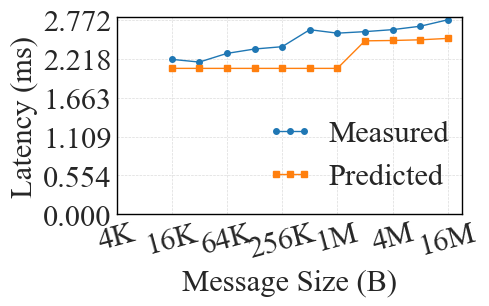

In [624]:
plot_latency_comparison(
    df=df_sweep_data_simple_ring_v1,
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='Latency (ms)',
    pdf_filename='reducescatter_ring_simple_pre_comparison.pdf',
    legend_x=0.7, 
    legend_y=0.3  
)

📄 Plot saved to: reducescatter_ring_simple_BW_pre_comparison.pdf


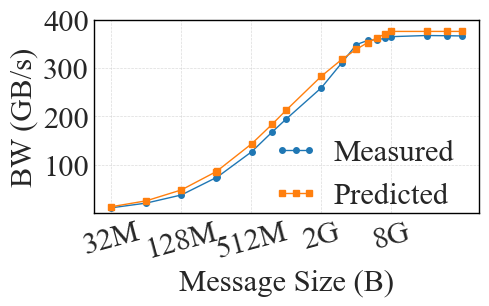

In [625]:
plot_BW_comparison(
    df=df_sweep_data_simple_ring_v1,
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='BW (GB/s)',
    pdf_filename='reducescatter_ring_simple_BW_pre_comparison.pdf',
    legend_x=0.7, 
    legend_y=0.2 
)

## LL

### Read from nccl-test data

In [626]:
# Example usage:
custom_thresholds = {
    4*1024: 1,
    8*1024: 2,
    16*1024: 4,
    32*1024: 8,
    float('inf'): 16
}
df_sweep_data_LL_means = parse_nccl_output("./LL_profiling_results/nccl_test-reducescatter-ring.out", gpus_per_node=gpus_per_node, msg_size_thresholds=custom_thresholds)

# with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
#     print(df_sweep_data_LL_means.to_pandas())

display(df_sweep_data_LL_means)

msg,latency (us),BW (GB/s),algorithm,nnodes,protocol,nchannels
i64,f64,f64,str,f64,str,i32
8192,608.7,0.01,"""RING""",16.0,"""LL""",2
16384,522.8,0.03,"""RING""",16.0,"""LL""",4
32768,523.0,0.06,"""RING""",16.0,"""LL""",8
65536,525.8,0.12,"""RING""",16.0,"""LL""",16
131072,530.6,0.25,"""RING""",16.0,"""LL""",16
…,…,…,…,…,…,…
16777216,1156.4,14.4,"""RING""",16.0,"""LL""",16
33554432,1415.9,23.51,"""RING""",16.0,"""LL""",16
67108864,2069.9,32.17,"""RING""",16.0,"""LL""",16


### Read from profiling

In [627]:
# === File Paths ===
profiling_files = {
    "r1": "./LL_profiling_results/nccl_reducescatter_heo-inter_r-1.out"
}

# === Load Data ===
df_r1_LL = parse_send_timings(profiling_files["r1"])

# with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
#         print(df_r1_LL.to_pandas())

display(df_r1_LL)


Number of records: 527


chunk_id,channel,source,dest,algo,protocol,message_size,nchannels,nmessages,iteration,T1,T2,T9,T8,T_init,T0,T7,T10
i64,i64,i64,i64,str,str,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
0,0,1,8,"""RING""","""LL""",0.003906,1,10000,0,0.012418,0.013535,0.100722,0.008854,2166.506592,0.0,0.086479,0.088304
1,0,1,8,"""RING""","""LL""",0.003906,1,10000,0,0.012418,0.013535,0.100722,0.008854,2166.506592,0.000073,0.084437,0.090414
2,0,1,8,"""RING""","""LL""",0.003906,1,10000,0,0.012418,0.013535,0.100722,0.008854,2166.506592,0.000149,0.083705,0.091939
3,0,1,8,"""RING""","""LL""",0.003906,1,10000,0,0.012418,0.013535,0.100722,0.008854,2166.506592,0.000228,0.082962,0.094072
4,0,1,8,"""RING""","""LL""",0.003906,1,10000,0,0.012418,0.013535,0.100722,0.008854,2166.506592,0.000312,0.08271,0.096413
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
26,0,1,8,"""RING""","""LL""",512.0,16,10000,0,0.038614,0.055646,0.181814,0.032353,2230.587646,0.248767,0.040307,0.272473
27,0,1,8,"""RING""","""LL""",512.0,16,10000,0,0.038614,0.055646,0.181814,0.032353,2230.587646,0.199389,0.027949,0.213628
28,0,1,8,"""RING""","""LL""",512.0,16,10000,0,0.038614,0.055646,0.181814,0.032353,2230.587646,0.159704,0.020349,0.173155


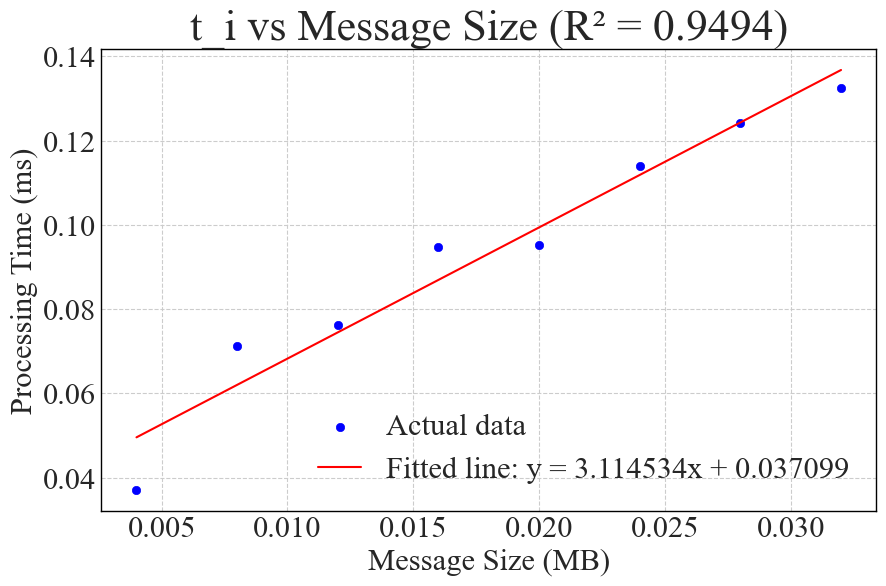

G_reverse = 3.115 (us/KB), L_G = 37.099 (us), R-squared value is 0.949357


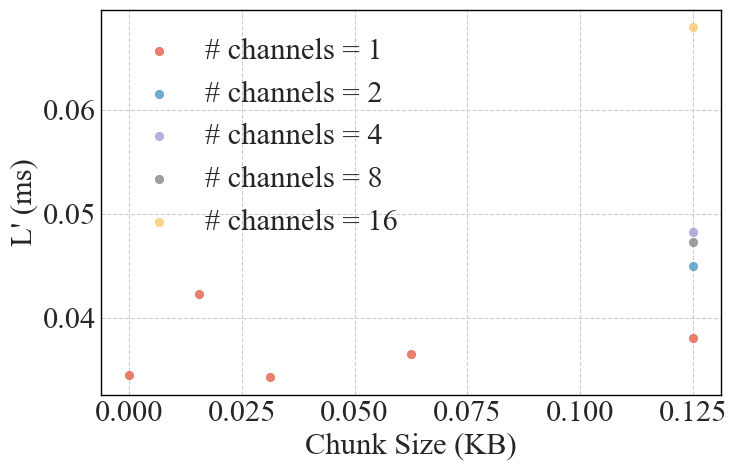

L_G = 40.771 (us)


In [628]:
FIFO_Depth = 8

nranks = 32
nchannels = 16
isend_chunk_size = 32 # KB
ring_chunk_size_ll = isend_chunk_size
slice_step = 1

# inflection_point2: now the chunk size is max, after this point, chunk size will not increase, chunk number increase.
inflection_point2 = isend_chunk_size * nchannels * slice_step

small_msg_start = 1/2

max_nchannels_start = 64

# L = analyze_L_timing(df_r1_LL, nranks, 1, small_msg_start, max_nchannels_start/2, 0)

# L_G, G_reverse are about the time of each 8n-1 chunk
G_reverse_ll, L_G_ll = analyze_G_v2_timing(df_r1_LL, slice_step, max_nchannels_start, inflection_point2, 1)

L_G_ll_ss = analyze_L_ss_timing(df_r1_LL, nranks, slice_step, G_reverse_ll, 0, max_nchannels_start, 1)

### Model Varification V1

msg,latency (us),BW (GB/s),algorithm,nnodes,protocol,nchannels,latency_pre (us),BW_pre (GB/s),prediction_error (%)
i64,f64,f64,str,f64,str,i32,f64,f64,f64
16384,522.8,0.03,"""RING""",16.0,"""LL""",4,647.232393,0.025116,23.801146
32768,523.0,0.06,"""RING""",16.0,"""LL""",8,647.232393,0.050232,23.753804
65536,525.8,0.12,"""RING""",16.0,"""LL""",16,647.232393,0.100465,23.094788
131072,530.6,0.25,"""RING""",16.0,"""LL""",16,647.232393,0.200929,21.981227
262144,551.2,0.47,"""RING""",16.0,"""LL""",16,647.232393,0.401859,17.422423
…,…,…,…,…,…,…,…,…,…
16777216,1156.4,14.4,"""RING""",16.0,"""LL""",16,984.488062,16.908426,14.866131
33554432,1415.9,23.51,"""RING""",16.0,"""LL""",16,1380.033846,24.124255,2.533099
67108864,2069.9,32.17,"""RING""",16.0,"""LL""",16,2171.125413,30.668231,4.890353


📄 Plot saved to: ./reducescatter_ring_LL_pre_error.pdf


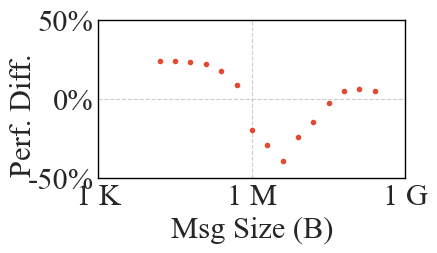

In [629]:
# use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.
number_channels = 16

df_sweep_data_LL_means = df_sweep_data_LL_means.filter(
        pl.col("msg") > 8192
)

max_nchannels_start_ll = max_nchannels_start

df_sweep_data_simple_ring_v1 = (df_sweep_data_LL_means
    .with_columns([
        pl
        .when(
            (pl.col("msg")/1024) < max_nchannels_start * pl.col("nnodes")*gpus_per_node  # when channels is not max
        )
        .then(
            L_G_ll_ss # time of each step
            * (pl.col("nnodes")*gpus_per_node-1) * slice_step # number of chunks per loop, only one loop now.
            / FIFO_Depth # total time = number of chunks * chunk time / FIFO_Depth
        )
        .when(  # Use .when instead of .else when
            (pl.col("msg")/1024) < (pl.col("nnodes")*gpus_per_node*pl.col("nchannels")*slice_step * isend_chunk_size)  # when chunk size is not max
        )
        .then(
            (G_reverse_ll * ((pl.col("msg")/1024) / (pl.col("nnodes")*gpus_per_node*pl.col("nchannels")*slice_step)) + L_G_ll) # time of each step
            * (pl.col("nnodes")*gpus_per_node-1) * slice_step # number of chunks per loop, only one loop now.
            / FIFO_Depth # total time = number of chunks * chunk time / FIFO_Depth
        )
        .otherwise(
            (G_reverse_ll * isend_chunk_size + L_G_ll) # time of each step
            * (((pl.col("msg")/1024) / (pl.col("nnodes")*gpus_per_node*pl.col("nchannels")*slice_step)) / isend_chunk_size) # number of loops
            * (pl.col("nnodes")*gpus_per_node-1) * slice_step # number of chunks per loop
            / FIFO_Depth # total time = number of chunks * chunk time / FIFO_Depth
        )
        .alias("latency_pre (us)")  # the bandwidth of each 4n-1 chunk
    ])
)

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_simple_ring_v1 = df_sweep_data_simple_ring_v1.with_columns([
    (pl.col("msg") * 1e6 / 1e9 * ((pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_simple_ring_v1_csv = df_sweep_data_simple_ring_v1.with_columns([
    ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
])

# with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
#         print(df_sweep_data_simple_ring_v1_csv.to_pandas())

display(df_sweep_data_simple_ring_v1_csv)

# df_sweep_data_simple_ring_v1_csv.to_pandas().to_csv('model0.csv', index=False)

plot_prediction_error(
    df_sweep_data_simple_ring_v1,
    figsize=(5, 3),
    pdf_filename="reducescatter_ring_LL_pre_error.pdf",
    y_ticks=[-0.50, 0.0, 0.50],
    y_labels=["-50%", "0%", "50%"],
    xlabel="Msg Size (B)",
    ylabel="Perf. Diff.",
    legend=False,
    protocol="LL"
)

📄 Plot saved to: reducescatter_ring_LL_pre_comparison.pdf


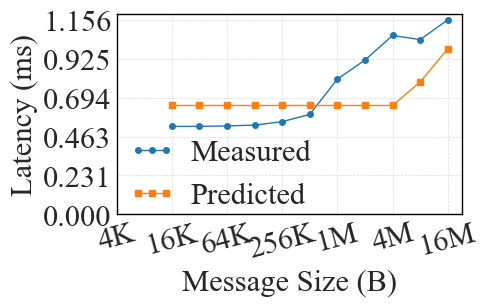

In [630]:
plot_latency_comparison(
    df=df_sweep_data_simple_ring_v1,
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='Latency (ms)',
    pdf_filename='reducescatter_ring_LL_pre_comparison.pdf',
    legend_x=0.3, 
    legend_y=0.2  
)

📄 Plot saved to: reducescatter_ring_LL_BW_pre_comparison.pdf


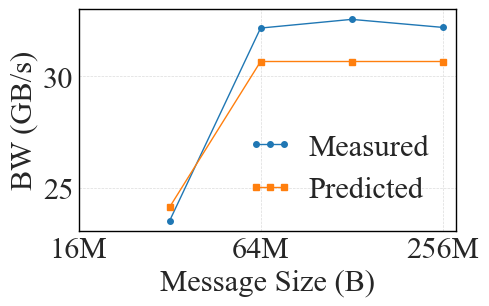

In [631]:
plot_BW_comparison(
    df=df_sweep_data_simple_ring_v1,
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='BW (GB/s)',
    pdf_filename='reducescatter_ring_LL_BW_pre_comparison.pdf',
    protocol="LL"
)

## LL128

### Read from nccl-test

In [632]:
# Example usage:
custom_thresholds = {
    1*1024: 2,
    2*1024: 4,
    4*1024: 8,
    float('inf'): 16
}
df_sweep_data_LL128_means = parse_nccl_output("./LL128_profiling_results/nccl_test-reducescatter-ring.out", gpus_per_node=gpus_per_node, msg_size_thresholds=custom_thresholds)

# with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
#     print(df_sweep_data_LL128_means.to_pandas())

display(df_sweep_data_LL128_means)

msg,latency (us),BW (GB/s),algorithm,nnodes,protocol,nchannels
i64,f64,f64,str,f64,str,i32
8192,664.2,0.01,"""RING""",16.0,"""LL128""",16
16384,579.8,0.03,"""RING""",16.0,"""LL128""",16
32768,732.4,0.04,"""RING""",16.0,"""LL128""",16
65536,850.3,0.08,"""RING""",16.0,"""LL128""",16
131072,1079.7,0.12,"""RING""",16.0,"""LL128""",16
…,…,…,…,…,…,…
7516192768,23193.0,321.53,"""RING""",16.0,"""LL128""",16
8589934592,26353.0,323.41,"""RING""",16.0,"""LL128""",16
17179869184,50540.0,337.27,"""RING""",16.0,"""LL128""",16


### Read from profiling

In [633]:
# === File Paths ===
profiling_files = {
    "r1": "./LL128_profiling_results/nccl_reducescatter_heo-inter_r-1.out"
}

# === Load Data ===
df_r1_LL128 = parse_send_timings(profiling_files["r1"])

# with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
#         print(df_r1_LL128.to_pandas())

display(df_r1_LL128)


Number of records: 744


chunk_id,channel,source,dest,algo,protocol,message_size,nchannels,nmessages,iteration,T1,T2,T9,T8,T_init,T0,T7,T10
i64,i64,i64,i64,str,str,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
0,0,1,8,"""RING""","""LL128""",0.003906,1,10000,0,0.010845,0.016156,0.101668,0.005078,2282.355957,0.0,0.084785,0.090823
1,0,1,8,"""RING""","""LL128""",0.003906,1,10000,0,0.010845,0.016156,0.101668,0.005078,2282.355957,0.000073,0.082327,0.093771
2,0,1,8,"""RING""","""LL128""",0.003906,1,10000,0,0.010845,0.016156,0.101668,0.005078,2282.355957,0.000145,0.080099,0.095182
3,0,1,8,"""RING""","""LL128""",0.003906,1,10000,0,0.010845,0.016156,0.101668,0.005078,2282.355957,0.000219,0.077686,0.096889
4,0,1,8,"""RING""","""LL128""",0.003906,1,10000,0,0.010845,0.016156,0.101668,0.005078,2282.355957,0.000291,0.075552,0.098633
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
26,0,1,8,"""RING""","""LL128""",8192.0,16,10000,0,0.026159,0.044333,0.229808,0.046302,2509.681641,0.6238,0.166616,0.821316
27,0,1,8,"""RING""","""LL128""",8192.0,16,10000,0,0.026159,0.044333,0.229808,0.046302,2509.681641,0.613112,0.156126,0.79084
28,0,1,8,"""RING""","""LL128""",8192.0,16,10000,0,0.026159,0.044333,0.229808,0.046302,2509.681641,0.587886,0.141595,0.742737


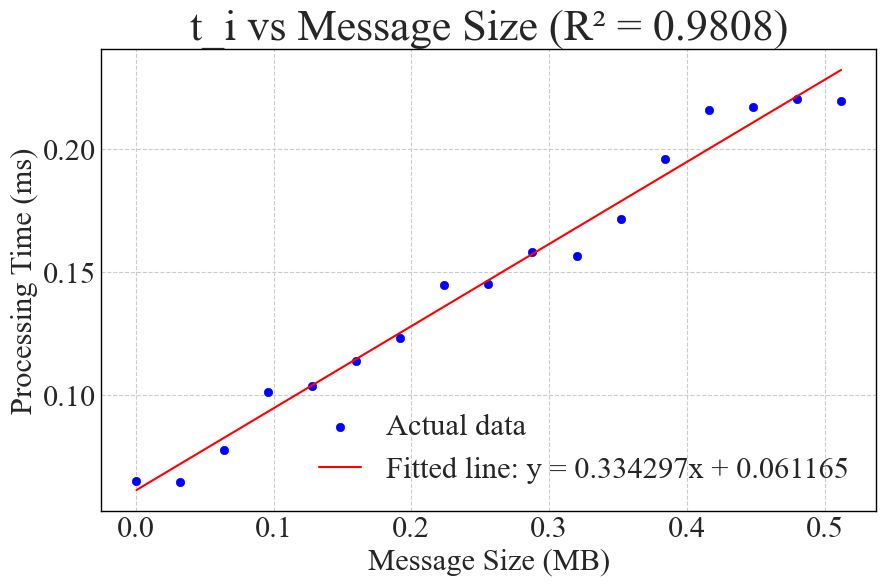

G_reverse = 0.334 (us/KB), L_G = 61.165 (us), R-squared value is 0.980813


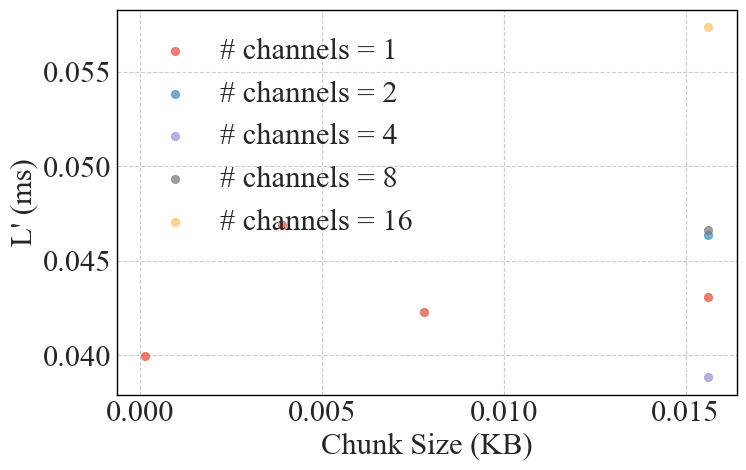

L_G = 43.423 (us)


In [634]:
FIFO_Depth = 8

nranks = 32
nchannels = 16
isend_chunk_size = 562 # KB
ring_chunk_size_ll128 = isend_chunk_size
slice_step = 1

# inflection_point2: now the chunk size is max, after this point, chunk size will not increase, chunk number increase.
inflection_point2 = isend_chunk_size * slice_step * nchannels

small_msg_start = 1/2

max_nchannels_start = 8

# L = analyze_L_timing(df_r1_LL128, nranks, 1, small_msg_start, max_nchannels_start/2, 0)

# L_G, G_reverse are about the time of each 8n-1 chunk
G_reverse_ll128, L_G_ll128 = analyze_G_v2_timing(df_r1_LL128, slice_step, max_nchannels_start, inflection_point2, 1)

L_G_ll128_ss = analyze_L_ss_timing(df_r1_LL128, nranks, slice_step, G_reverse_ll128, 0, max_nchannels_start, 1)

msg,latency (us),BW (GB/s),algorithm,nnodes,protocol,nchannels,latency_pre (us),BW_pre (GB/s),prediction_error (%)
i64,f64,f64,str,f64,str,i32,f64,f64,f64
16384,579.8,0.03,"""RING""",16.0,"""LL128""",16,689.33308,0.023582,18.891528
32768,732.4,0.04,"""RING""",16.0,"""LL128""",16,689.33308,0.047164,5.880246
65536,850.3,0.08,"""RING""",16.0,"""LL128""",16,689.33308,0.094329,18.930603
131072,1079.7,0.12,"""RING""",16.0,"""LL128""",16,689.33308,0.188658,36.155128
262144,923.2,0.28,"""RING""",16.0,"""LL128""",16,689.33308,0.377315,25.332205
…,…,…,…,…,…,…,…,…,…
7516192768,23193.0,321.53,"""RING""",16.0,"""LL128""",16,25212.396966,295.785939,8.706924
8589934592,26353.0,323.41,"""RING""",16.0,"""LL128""",16,28814.167962,295.785939,9.339233
17179869184,50540.0,337.27,"""RING""",16.0,"""LL128""",16,57628.335923,295.785939,14.0252


📄 Plot saved to: ./reducescatter_ring_LL128_pre_error.pdf


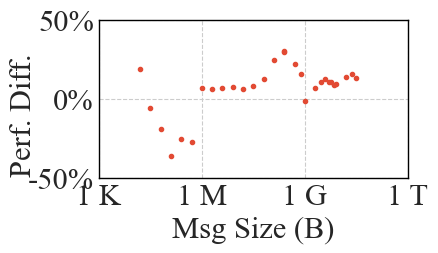

In [635]:
# use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.
number_channels = 16

df_sweep_data_LL128_means = df_sweep_data_LL128_means.filter(
        pl.col("msg") > 8192
)

max_nchannels_start_ll128 = max_nchannels_start

df_sweep_data_simple_ring_v1 = (df_sweep_data_LL128_means
    .with_columns([
        pl
        .when(
            (pl.col("msg")/1024) < max_nchannels_start * pl.col("nnodes")*gpus_per_node # when channels is not max
        )
        .then(
            L_G_ll128_ss # time of each step
            * (pl.col("nnodes")*gpus_per_node-1) * slice_step # number of chunks per loop, only one loop now.
            / FIFO_Depth # total time = number of chunks * chunk time / FIFO_Depth
        )
        .when(  # Use .when instead of .else when
            (pl.col("msg")/1024) < (pl.col("nnodes")*gpus_per_node*pl.col("nchannels")*slice_step * isend_chunk_size)  # when chunk size is not max
        )
        .then(
            (G_reverse_ll128 * ((pl.col("msg")/1024) / (pl.col("nnodes")*gpus_per_node*pl.col("nchannels")*slice_step)) + L_G_ll128) # time of each step
            * (pl.col("nnodes")*gpus_per_node-1) * slice_step # number of chunks per loop, only one loop now.
            / FIFO_Depth # total time = number of chunks * chunk time / FIFO_Depth
        )
        .otherwise(
            (G_reverse_ll128 * isend_chunk_size + L_G_ll128) # time of each step
            * (((pl.col("msg")/1024) / (pl.col("nnodes")*gpus_per_node*pl.col("nchannels")*slice_step)) / isend_chunk_size) # number of loops
            * (pl.col("nnodes")*gpus_per_node-1) * slice_step # number of chunks per loop
            / FIFO_Depth # total time = number of chunks * chunk time / FIFO_Depth
        )
        .alias("latency_pre (us)")  # the bandwidth of each 4n-1 chunk
    ])
)

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_simple_ring_v1 = df_sweep_data_simple_ring_v1.with_columns([
    (pl.col("msg") * 1e6 / 1e9 * ((pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_simple_ring_v1_csv = df_sweep_data_simple_ring_v1.with_columns([
    ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
])

# with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
#         print(df_sweep_data_simple_ring_v1_csv.to_pandas())

display(df_sweep_data_simple_ring_v1_csv)

# df_sweep_data_simple_ring_v1_csv.to_pandas().to_csv('model0.csv', index=False)


plot_prediction_error(
    df_sweep_data_simple_ring_v1,
    figsize=(5, 3),
    pdf_filename="reducescatter_ring_LL128_pre_error.pdf",
    y_ticks=[-0.50, 0.0, 0.50],
    y_labels=["-50%", "0%", "50%"],
    xlabel="Msg Size (B)",
    ylabel="Perf. Diff.",
    legend=False,
    protocol="LL128"
)

📄 Plot saved to: reducescatter_ring_LL128_pre_comparison.pdf


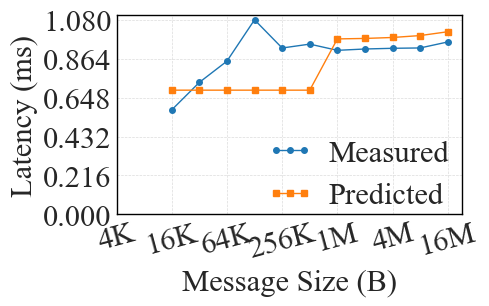

In [636]:
plot_latency_comparison(
    df=df_sweep_data_simple_ring_v1,
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='Latency (ms)',
    pdf_filename='reducescatter_ring_LL128_pre_comparison.pdf',
    legend_x=0.7, 
    legend_y=0.2  
)

📄 Plot saved to: reducescatter_ring_LL128_BW_pre_comparison.pdf


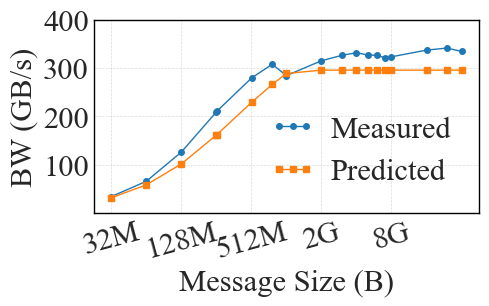

In [637]:
plot_BW_comparison(
    df=df_sweep_data_simple_ring_v1,
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='BW (GB/s)',
    pdf_filename='reducescatter_ring_LL128_BW_pre_comparison.pdf' 
)

In [638]:
# Create the formatted strings with the G values
print("// {LL, LL128, Simple}")
print(f".ring_G_reverse = {{{G_reverse_ll:.6f}, {G_reverse_ll128:.6f}, {G_reverse:.6f}}}, // (us/KB)")
print(f".ring_L_G = {{{L_G_ll:.6f}, {L_G_ll128:.6f}, {L_G:.6f}}}, // (us)")
print(f".ring_L_G_ss = {{{L_G_ll_ss:.6f}, {L_G_ll128_ss:.6f}, {L_G_ss:.6f}}}, // (us)")
print(f".ring_max_nchannels_start = {{{max_nchannels_start_ll:.6f}, {max_nchannels_start_ll128:.6f}, {max_nchannels_start_simple:.6f}}}, // (KB)")
print(f".ring_chunk_size = {{{ring_chunk_size_ll:.6f}, {ring_chunk_size_ll128:.6f}, {ring_chunk_size_simple:.6f}}}, // (KB)")

print(f".ring_1/G_reverse = {{{1e6*16*8/(G_reverse_ll*1024*1024):.6f}, {1e6*16*8/(G_reverse_ll128*1024*1024):.6f}, {1e6*16*4/(G_reverse*1024*1024):.6f}}}, // (GB/s)")

// {LL, LL128, Simple}
.ring_G_reverse = {3.114534, 0.334297, 0.155345}, // (us/KB)
.ring_L_G = {37.098726, 61.164608, 38.861511}, // (us)
.ring_L_G_ss = {40.770544, 43.422556, 32.760786}, // (us)
.ring_max_nchannels_start = {64.000000, 8.000000, 16.000000}, // (KB)
.ring_chunk_size = {32.000000, 562.000000, 2048.000000}, // (KB)
.ring_1/G_reverse = {39.193768, 365.154781, 392.901882}, // (GB/s)
